In [118]:
import matplotlib.pyplot as plt 
import numpy as np 
import cv2 as cv

Baris kode tersebut berfungsi untuk mengimpor tiga library utama yang akan digunakan dalam pengolahan citra: OpenCV (cv) untuk membaca dan memanipulasi gambar, NumPy (np) untuk mengolah struktur matriks angka pada piksel, dan Matplotlib (plt) untuk menampilkan hasil gambar serta grafik ke layar.

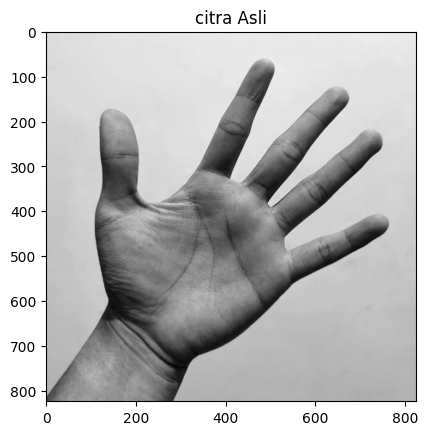

In [119]:
tangan = cv.imread("telapak.png")
tangan = cv.cvtColor(tangan, cv.COLOR_BGR2GRAY)
plt.title("citra Asli")
plt.imshow(tangan, cmap='gray')

Kode tersebut berfungsi untuk membaca gambar bernama "tangan.jpeg", mengubah warnanya menjadi hitam-putih (grayscale), lalu menampilkannya ke layar menggunakan Matplotlib.

In [120]:
def resize(image, new_width, new_height):
    old_height, old_width = image.shape[:2]
    resized_image = np.zeros((new_height, new_width), dtype=np.uint8)
    for i in range(new_height):
        for j in range(new_width):
            x = int(j * old_width / new_width)
            y = int(i * old_height / new_height)
            resized_image[i, j] = image[y, x]
    return resized_image

Fungsi ini digunakan untuk mengubah ukuran (resize) gambar grayscale secara manual menggunakan algoritma Nearest Neighbor Interpolation.

Cara kerjanya adalah dengan membuat kanvas kosong baru sesuai ukuran target (new_height dan new_width), lalu melakukan perulangan untuk mengisi setiap piksel baru dengan cara memetakan koordinatnya kembali ke posisi piksel terdekat pada gambar asli (image).

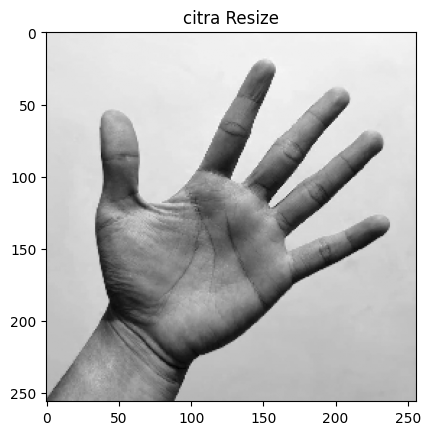

In [121]:
tangan = resize(tangan, 256, 256)
plt.title("citra Resize")
plt.imshow(tangan, cmap='gray')

Kode tersebut berfungsi untuk mengubah ukuran (resize) gambar "tangan" secara manual menggunakan fungsi resize yang sudah dibuat sebelumnya, lalu menampilkan hasilnya ke layar dengan judul "citra Resize".

In [122]:
def convolution(img, kernel):
    size = kernel.shape[0]
    pad = size // 2
    padded = np.pad(img, pad, mode='constant')
    h, w = img.shape[:2]
    hasil = np.zeros_like(img).astype(np.float32)

    for i in range(h):
        for j in range(w):
            region = padded[i:i+size, j:j+size]
            hasil[i, j] = np.sum(region * kernel)
    return hasil

Fungsi ini digunakan untuk melakukan operasi konvolusi matriks secara manual pada gambar grayscale, yang biasanya dipakai untuk proses pemfilteran citra (filtering), seperti penghalusan (blurring) atau deteksi tepi.

Cara kerjanya adalah dengan menambahkan bingkai kosong di sekeliling gambar (padding) agar ukurannya tidak mengecil, lalu menggeser matriks kernel ke setiap piksel gambar untuk mengalikan elemen yang bertumpang-tindih dan menjumlahkan hasilnya (np.sum) sebagai nilai piksel baru.

In [123]:
def sobel_edge_detection(img):
    Kx = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
    Ky = np.array([[1, 2, 1], [0, 0, 0], [-1, -2, -1]])
    Ix = convolution(img, Kx)
    Iy = convolution(img, Ky)
    magnitude = np.sqrt(Ix**2 + Iy**2)
    return np.clip(magnitude, 0, 255).astype(np.uint8)

Fungsi ini digunakan untuk melakukan deteksi tepi objek menggunakan metode Sobel pada gambar grayscale.
Cara kerjanya adalah dengan mencari perubahan kontras gambar dalam dua arah, yaitu garis tepi vertikal dan horizontal secara terpisah menggunakan fungsi konvolusi. Kedua hasil arah tersebut kemudian digabungkan untuk menghasilkan gambar akhir yang hanya memperlihatkan garis kontur atau tepian objek secara utuh.

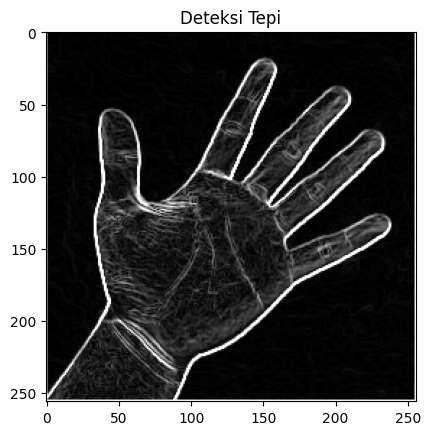

In [124]:
tanganDeteksi = sobel_edge_detection(tangan)
plt.title("Deteksi Tepi")
plt.imshow(tanganDeteksi, cmap='gray')

Kode tersebut berfungsi untuk menjalankan fungsi deteksi tepi Sobel pada gambar tangan yang sudah di-resize sebelumnya, lalu menampilkan hasilnya ke layar dalam bentuk hitam-putih (grayscale) dengan judul "Deteksi Tepi".

In [125]:
def thresholding(img, threshold):
    rows, cols = img.shape
    canvas = np.zeros_like(img, dtype=np.uint8)
    for i in range(rows):
        for j in range(cols):
            if(img[i,j] > threshold):
                canvas[i,j] = 255
            elif(img[i,j] <= threshold):
                canvas[i,j] = 0
    return canvas

def threshold(image, value, min_val, max_val):
    img = np.array(image)
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            if img[i, j] <= value:
                img[i, j] = max_val
            else:
                img[i, j] = min_val 
    return img

Kode ini berisi dua fungsi untuk melakukan thresholding (pengambangan) secara manual guna mengubah gambar grayscale menjadi gambar biner (hitam-putih mutlak).

thresholding: Fungsi pertama yang mengubah piksel menjadi putih (255) jika nilainya berada di atas threshold, dan menjadi hitam (0) jika nilainya berada di bawah atau sama dengan threshold.

threshold: Fungsi kedua yang bekerja dengan logika terbalik, yaitu mengubah piksel menjadi nilai maksimal (max_val) jika berada di bawah atau sama dengan batas, dan menjadi nilai minimal (min_val) jika berada di atas batas.

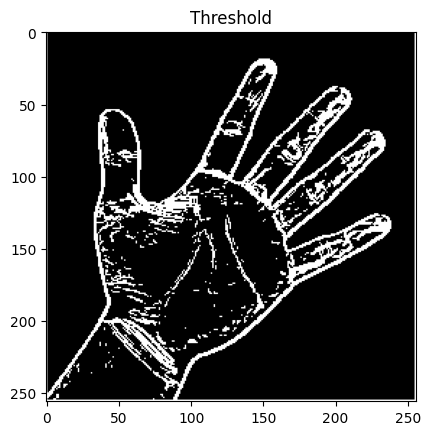

In [126]:
tanganThres = thresholding(tanganDeteksi, 60)
plt.title("Threshold")
plt.imshow(tanganThres, cmap='gray')

Kode tersebut berfungsi untuk menjalankan fungsi thresholding pada gambar hasil deteksi tepi (tanganDeteksi) dengan nilai batas (threshold) sebesar 60, lalu menampilkan hasilnya ke layar sebagai gambar biner (hitam-putih mutlak) dengan judul "Threshold".

In [127]:
kernel_cross_satu = np.array([
    [1,1,1],
    [1,1,1],
    [1,1,1]
], dtype=np.uint8)


kernel_cross = np.array([
    [0,1,0],
    [1,1,1],
    [0,1,0]
], dtype=np.uint8)


kernel_kotak = np.array([ 
    [1,1,1,1,1], 
    [1,1,1,1,1], 
    [1,1,1,1,1], 
    [1,1,1,1,1], 
    [1,1,1,1,1] 
], dtype=np.uint8) 

kernel = np.ones((3, 3), np.uint8)

kode diatas digunakan untuk mendefinisikan kernel 3x3 dan 5x5 yang nanti akan digunakan untuk menghitung piksel citra nantinya

In [128]:
def dilation(image, kernel):
    height, width = image.shape
    k_height, k_width = kernel.shape
    center = k_height // 2
    result = np.zeros((height, width), dtype=np.uint8)
    for i in range(center, height - center):
        for j in range(center, width - center):
            if image[i,j] == 255:
                for k in range(k_height):
                    for l in range(k_width):
                        if kernel[k,l] == 1:
                            result[i+k-center, j+l-center] = 255
            else:
                if result[i,j] != 255:
                    result[i,j] = 0
    return result

Fungsi ini digunakan untuk melakukan operasi dilatasi morfologi secara manual pada gambar biner (hitam-putih).

Cara kerjanya adalah dengan mempertebal atau memperluas area objek berwarna putih (255). Jika fungsi menemukan piksel putih pada gambar asli, matriks kernel akan ditempatkan di titik tersebut, lalu semua piksel di sekitarnya yang terkena area kernel bernilai 1 akan ikut diubah menjadi putih.

In [129]:
def erosion(image, kernel):
    height, width = image.shape
    k_height, k_width = kernel.shape
    center = k_height // 2
    result = np.zeros_like(image, dtype=np.uint8)
    for i in range(center, height - center):
        for j in range(center, width - center):
            match = True
            for k in range(k_height):
                for l in range(k_width):
                    if kernel[k, l] == 1 and image[i + k - center, j + l - center] == 0:
                        match = False
                        break
                if not match:
                    break
            if match:
                result[i, j] = 255
    return result

Fungsi ini digunakan untuk melakukan operasi erosi morfologi secara manual pada gambar biner (hitam-putih).

Cara kerjanya adalah dengan menipiskan atau mengikis area objek berwarna putih (255). Fungsi ini akan memeriksa setiap piksel menggunakan matriks kernel; jika seluruh area gambar yang tertutup oleh bagian kernel bernilai 1 semuanya berwarna putih (match), maka piksel pusatnya akan dipertahankan tetap putih. Namun, jika ada satu saja piksel yang bocor atau menyentuh warna hitam (0), maka piksel pusat tersebut akan dikikis menjadi hitam.

In [130]:
def thinning(img):
    binary = (img > 0).astype(np.uint8)
    height, width = binary.shape
    changed = True
    while changed:
        changed = False
        to_delete = []
        # STEP 1
        for i in range(1, height-1):
            for j in range(1, width-1):
                P1 = binary[i, j]
                if P1 != 1:
                    continue
                P2 = binary[i-1, j]
                P3 = binary[i-1, j+1]
                P4 = binary[i, j+1]
                P5 = binary[i+1, j+1]
                P6 = binary[i+1, j]
                P7 = binary[i+1, j-1]
                P8 = binary[i, j-1]
                P9 = binary[i-1, j-1]
                neighbors = [P2,P3,P4,P5,P6,P7,P8,P9]
                sum_neighbors = np.sum(neighbors)
                transitions = 0
                sequence = neighbors + [P2]
                for k in range(8):
                    if sequence[k] == 0 and sequence[k+1] == 1:
                        transitions += 1
                if (
                    2 <= sum_neighbors <= 6 and
                    transitions == 1 and
                    P2 * P4 * P6 == 0 and
                    P4 * P6 * P8 == 0
                ):
                    to_delete.append((i,j))
        if to_delete:
            changed = True
            for i,j in to_delete:
                binary[i,j] = 0
            to_delete = []
        # STEP 2
        for i in range(1, height-1):
            for j in range(1, width-1):
                P1 = binary[i, j]
                if P1 != 1:
                    continue
                P2 = binary[i-1, j]
                P3 = binary[i-1, j+1]
                P4 = binary[i, j+1]
                P5 = binary[i+1, j+1]
                P6 = binary[i+1, j]
                P7 = binary[i+1, j-1]
                P8 = binary[i, j-1]
                P9 = binary[i-1, j-1]
                neighbors = [P2,P3,P4,P5,P6,P7,P8,P9]
                sum_neighbors = np.sum(neighbors)
                transitions = 0
                sequence = neighbors + [P2]
                for k in range(8):
                    if sequence[k] == 0 and sequence[k+1] == 1:
                        transitions += 1
                if (
                    2 <= sum_neighbors <= 6 and
                    transitions == 1 and
                    P2 * P4 * P8 == 0 and
                    P2 * P6 * P8 == 0
                ):
                    to_delete.append((i,j))
        if to_delete:
            changed = True
            for i,j in to_delete:
                binary[i,j] = 0
    return binary * 255

Fungsi ini menerapkan Algoritma Zhang-Suen Skeletonization untuk melakukan operasi thinning (penipisan) pada gambar biner secara manual.

Cara kerjanya adalah dengan mengikis piksel-piksel di bagian tepi objek secara berulang-ulang (looping while) melalui dua tahapan seleksi (Step 1 dan Step 2) yang memeriksa jumlah tetangga serta pola perubahan warna piksel di sekelilingnya. Proses pengikisan ini akan terus berjalan dan baru berhenti ketika objek sudah sekecil mungkin (menyisakan rangka utama setebal satu piksel) tanpa memutus struktur asli objek tersebut.

In [131]:
def thickening(img, kernel, iterations=1):
    result = img.copy()
    for _ in range(iterations):
        result = dilation(result, kernel)
    return result

Fungsi ini digunakan untuk melakukan operasi thickening (penebalan) objek biner secara manual dengan memanfaatkan fungsi dilatasi yang sudah dibuat sebelumnya.

Cara kerjanya adalah dengan menduplikasi gambar asli, lalu menjalankan proses dilatasi sebanyak jumlah perulangan yang diinginkan (iterations). Setiap iterasi akan menambahkan lapisan piksel putih di sekeliling tepi luar objek, sehingga ukuran objek menjadi lebih tebal dan padat.

In [132]:
def morphological_gradient(img, kernel):
    dilated = dilation(img, kernel)
    eroded = erosion(img, kernel)
    gradient = dilated.astype(np.int16) - eroded.astype(np.int16)
    return np.clip(gradient, 0, 255).astype(np.uint8)

Fungsi ini digunakan untuk melakukan operasi morphological gradient (gradien morfologi) secara manual pada gambar biner.

Cara kerjanya adalah dengan mendeteksi garis tepi objek melalui selisih hasil morfologi. Fungsi ini akan mendilatasi (mempertebal) dan mengerosi (menipiskan) gambar asli terlebih dahulu menggunakan kernel yang sama. Hasil dilatasi kemudian dikurangi dengan hasil erosi, sehingga area tengah objek yang sama akan terhapus dan menyisakan garis kontur atau batas tepi objek yang bersih.

In [133]:
def opening(image, kernel):
    return dilation(erosion(image, kernel), kernel)

def closing(image, kernel):
    return erosion(dilation(image, kernel), kernel)

def gradien_morph(image, kernel):
    return dilation(image, kernel) - erosion(image, kernel)

Kode ini berisi tiga fungsi untuk operasi morfologi tingkat lanjut pada gambar biner menggunakan gabungan fungsi erosi dan dilatasi:

opening: Berfungsi untuk menghilangkan derau (noise) kecil atau detail halus yang terpisah di luar objek utama. Cara kerjanya adalah dengan melakukan erosi dahulu, lalu dilatasi.

closing: Berfungsi untuk menutup lubang-lubang kecil atau menyambung retakan di dalam objek utama. Cara kerjanya adalah dengan melakukan dilatasi dahulu, lalu erosi.

gradien_morph: Berfungsi untuk mengambil garis tepi (kontur) objek. Cara kerjanya sama dengan fungsi sebelumnya, yaitu mengurangi hasil dilatasi dengan hasil erosi.

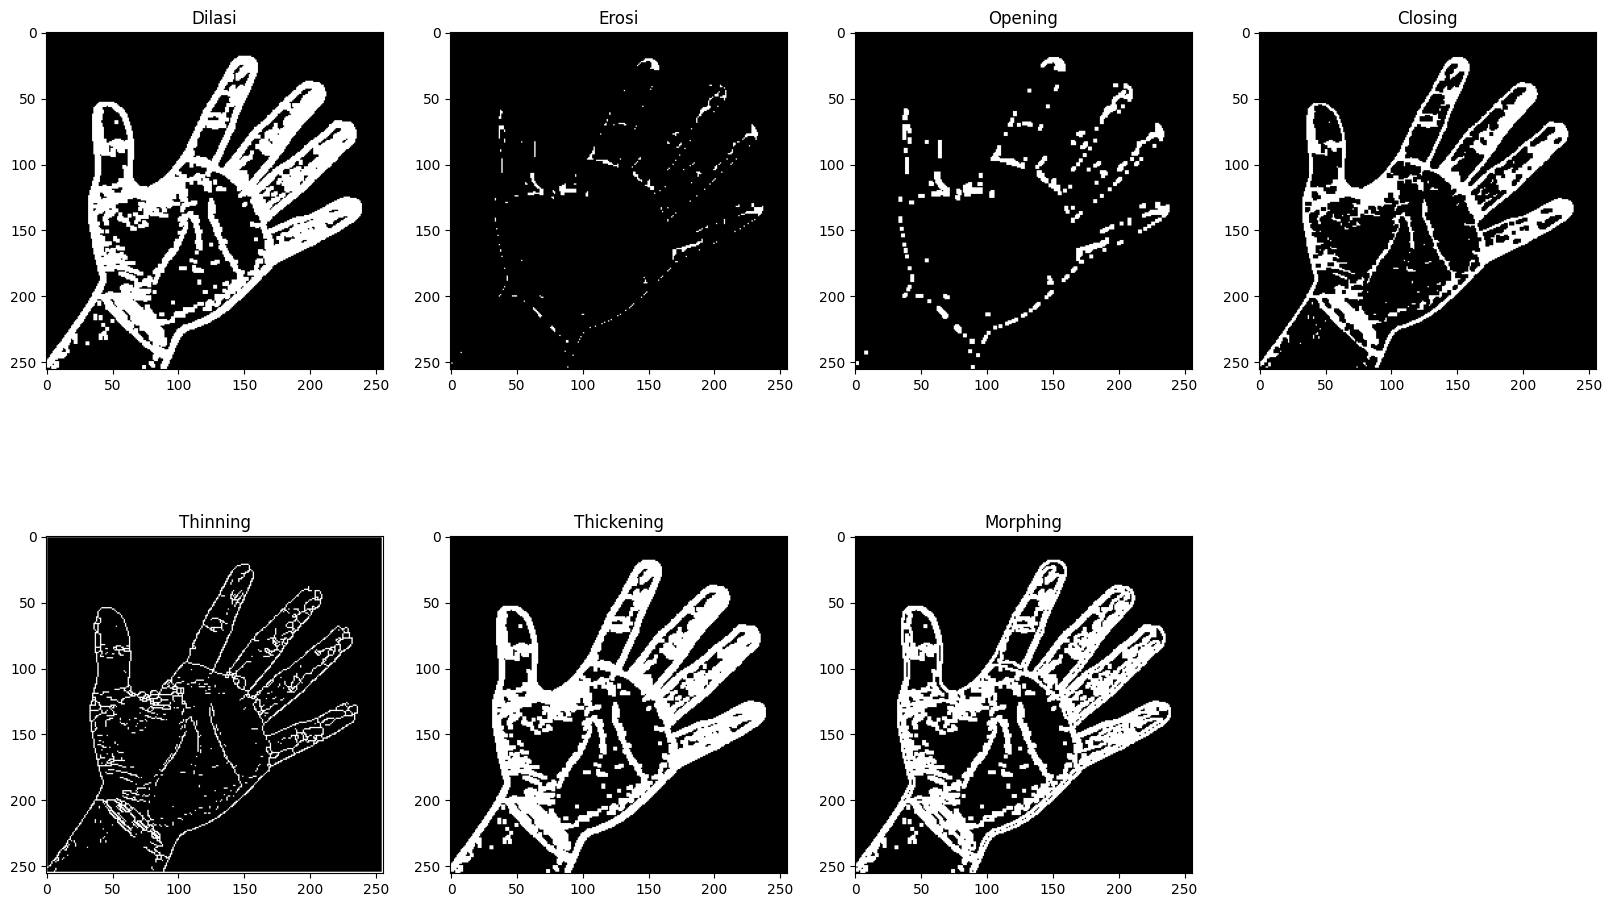

In [134]:
tangan_dilatasi = dilation(tanganThres, kernel_cross_satu)
tangan_erosi = erosion(tanganThres, kernel_cross_satu)
tangan_opening = opening(tanganThres, kernel_cross_satu)
tangan_closing = closing(tanganThres, kernel_cross_satu)
tangan_thinning = thinning(tanganThres)
tangan_thickening = thickening(tanganThres, kernel_cross_satu)
tangan_morph = morphological_gradient(tanganThres, kernel_cross_satu)

plt.figure(figsize=(20, 12))

plt.subplot(2, 4, 1)
plt.title("Dilasi")
plt.imshow(tangan_dilatasi, cmap='gray')
plt.subplot(2, 4, 2)
plt.title("Erosi")
plt.imshow(tangan_erosi, cmap='gray')
plt.subplot(2, 4, 3)
plt.title("Opening")
plt.imshow(tangan_opening, cmap='gray')
plt.subplot(2, 4, 4)
plt.title("Closing")
plt.imshow(tangan_closing, cmap='gray')
plt.subplot(2, 4, 5)
plt.title("Thinning")
plt.imshow(tangan_thinning, cmap='gray')
plt.subplot(2, 4, 6)
plt.title("Thickening")
plt.imshow(tangan_thickening, cmap='gray')
plt.subplot(2, 4, 7)
plt.title("Morphing")
plt.imshow(tangan_morph, cmap='gray')

plt.show()

Kode tersebut berfungsi untuk menerapkan berbagai macam operasi morfologi citra sekaligus pada gambar biner (tanganThres) menggunakan kernel silang (kernel_cross_satu), lalu menampilkan semua hasilnya dalam satu jendela/layout secara berdampingan.

Berikut adalah garis besar efek dari masing-masing hasil yang ditampilkan:

Dilasi: Objek putih terlihat lebih tebal/luas.

Erosi: Objek putih terlihat lebih tipis/terkikis.

Opening: Menghilangkan noise atau bintik putih kecil di luar objek.

Closing: Menutup lubang atau celah hitam kecil di dalam objek.

Thinning: Menyusutkan objek hingga menjadi garis rangka setebal 1 piksel.

Thickening: Mempertebal objek secara berulang (mirip dilasi bertingkat).

Morphing (Gradien Morfologi): Mengambil dan menampilkan garis tepi/kontur luar dari objek saja.

**Analisis Kernel 3x3:**

**Dilasi** memperluas piksel putih ke seluruh tetangga sesuai kernel 3x3. Garis-garis tepi telapak tangan terlihat lebih tebal dan beberapa celah kecil yang sebelumnya terputus menjadi tersambung kembali.

**Erosi** mengikis lapisan terluar piksel putih sehingga garis-garis menjadi lebih tipis. Noise berukuran lebih kecil dari kernel akan hilang sepenuhnya, menghasilkan citra yang lebih bersih namun garis halus bisa ikut terkikis.

**Opening** (erosi → dilasi) membersihkan noise kecil di sekitar kontur tanpa terlalu mengubah ukuran objek utama. Garis tepi terlihat lebih rapi dibanding citra threshold asli.

**Closing** (dilasi → erosi) menutup celah-celah kecil pada garis kontur sehingga kontur tangan terlihat lebih solid dan sambungan antar segmen garis lebih kontinyu.

**Thinning** menipiskan semua garis hingga tersisa satu piksel, menghasilkan representasi kerangka (skeleton) telapak tangan. Algoritma ini tidak menggunakan kernel melainkan aturan piksel tetangga.

**Thickening** menebalkan objek dengan melakukan thinning pada komplemen citra. Hasilnya garis-garis tepi menjadi jauh lebih lebar dan area sekitar kontur mulai terisi putih.

**Gradient Morfologi** (dilasi − erosi) menghasilkan kontur tepi yang bersih. Hanya piksel di batas transisi objek dan latar yang memiliki nilai positif, sehingga hasilnya menyerupai deteksi tepi namun berbasis struktur biner.

Kita menggunakan kernel ukuran 3x3 dengan setiap isi kernel adalah 1.

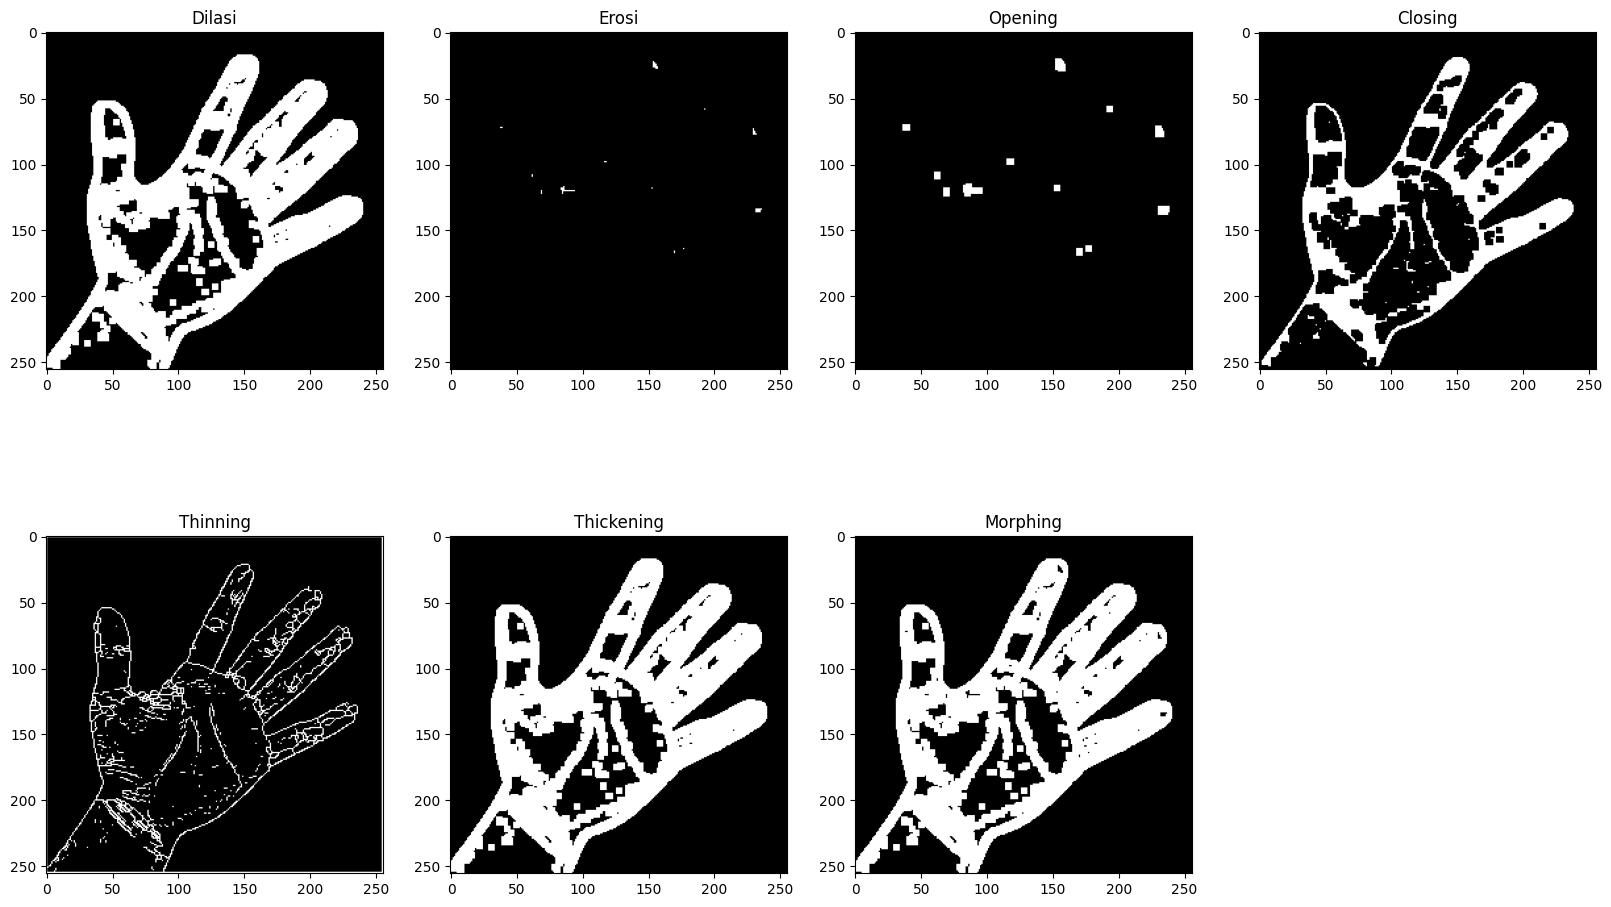

In [135]:
tangan_dilatasi5 = dilation(tanganThres, kernel_kotak)
tangan_erosi5 = erosion(tanganThres, kernel_kotak)
tangan_opening5 = opening(tanganThres, kernel_kotak)
tangan_closing5 = closing(tanganThres, kernel_kotak)
tangan_thinning5 = thinning(tanganThres)
tangan_thickening5 = thickening(tanganThres, kernel_kotak)
tangan_morph5 = morphological_gradient(tanganThres, kernel_kotak)

plt.figure(figsize=(20, 12))

plt.subplot(2, 4, 1)
plt.title("Dilasi")
plt.imshow(tangan_dilatasi5, cmap='gray')
plt.subplot(2, 4, 2)
plt.title("Erosi")
plt.imshow(tangan_erosi5, cmap='gray')
plt.subplot(2, 4, 3)
plt.title("Opening")
plt.imshow(tangan_opening5, cmap='gray')
plt.subplot(2, 4, 4)
plt.title("Closing")
plt.imshow(tangan_closing5, cmap='gray')
plt.subplot(2, 4, 5)
plt.title("Thinning")
plt.imshow(tangan_thinning5, cmap='gray')
plt.subplot(2, 4, 6)
plt.title("Thickening")
plt.imshow(tangan_thickening5, cmap='gray')
plt.subplot(2, 4, 7)
plt.title("Morphing")
plt.imshow(tangan_morph5, cmap='gray')

plt.show()

sama seperti sebelumnya, cuman yang berbeda hanya pada pemanggilan parameter kernel, kernel yang digunakan sekarang adalah kernel ukuran 5x5 yang isi dari setiap baris di kernel tersebut adalah 1

**Analisis Kernel 5x5 vs 3x3:**

**Ketebalan objek** — Dengan kernel 5x5 yang lebih besar, efek setiap operasi menjadi jauh lebih agresif. Dilasi menghasilkan garis yang jauh lebih tebal dibanding kernel 3x3 karena setiap piksel putih menyebarkan pengaruhnya ke area yang lebih luas (radius 2 piksel vs 1 piksel).

**Tingkat noise** — Erosi dengan kernel 5x5 lebih efektif menghilangkan noise karena syaratnya lebih ketat. Hanya piksel yang memiliki tetangga putih penuh dalam area 5x5 yang dipertahankan. Hasilnya lebih bersih namun objek utama juga mengecil lebih signifikan, bahkan garis tipis bisa hilang sama sekali.

**Detail citra** — Opening dengan kernel 5x5 menghasilkan citra yang sangat bersih dari noise tetapi kehilangan banyak detail garis halus karena erosi awal terlalu agresif. Dibandingkan 3x3 yang masih mempertahankan sebagian besar struktur, kernel 5x5 lebih cocok ketika kebersihan citra lebih diprioritaskan daripada detail.

**Bentuk objek** — Closing dengan 5x5 menutup celah yang lebih besar sehingga area telapak tangan terlihat lebih solid. Namun detail seperti celah antar jari yang seharusnya ada juga bisa ikut tertutup jika jaraknya lebih kecil dari ukuran kernel.

**Thinning** identik antara 3x3 dan 5x5 karena algoritma Zhang-Suen tidak menggunakan kernel.

Kita menggunakan kernel ukuran 5x5 dengan setiap isi kernel adalah 1.

Opening = erosi, dilasi

Closing = dilasi, erosi

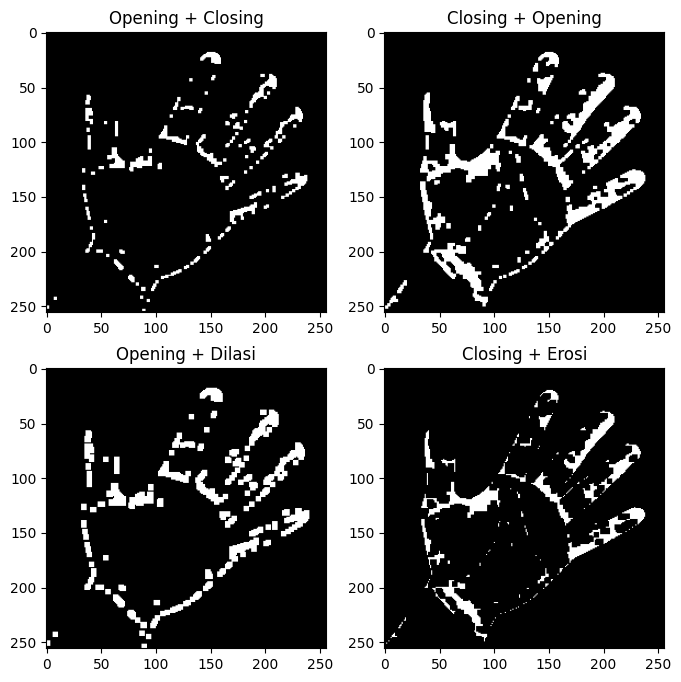

In [136]:
telapakKiriAtas = closing(tangan_opening, kernel_cross_satu)
telapakKiriBawah = dilation(tangan_opening, kernel_cross_satu)
telapakKananAtas = opening(tangan_closing, kernel_cross_satu)
telapakKananBawah = erosion(tangan_closing, kernel_cross_satu)

plt.figure(figsize=(8, 8))

plt.subplot(2, 2, 1)
plt.title("Opening + Closing")
plt.imshow(telapakKiriAtas, cmap='gray')
plt.subplot(2, 2, 2)
plt.title("Closing + Opening")
plt.imshow(telapakKananAtas, cmap='gray')
plt.subplot(2, 2, 3)
plt.title("Opening + Dilasi")
plt.imshow(telapakKiriBawah, cmap='gray')
plt.subplot(2, 2, 4)
plt.title("Closing + Erosi")
plt.imshow(telapakKananBawah, cmap='gray')

plt.show()

Kode tersebut berfungsi untuk melakukan kombinasi dua operasi morfologi secara berurutan pada gambar biner menggunakan kernel silang, lalu menampilkan hasil perbandingannya dalam bentuk grid $2 \times 2$.Tujuan utama dari kombinasi ini adalah untuk membersihkan derau (noise) secara lebih maksimal:Opening + Closing: Menghilangkan bintik putih di luar objek terlebih dahulu, baru kemudian menutup lubang hitam di dalam objek.Opening + Dilasi: Menghilangkan bintik putih kecil, lalu mempertebal kembali ukuran objek yang tersisa.Closing + Opening: Menutup lubang hitam di dalam objek terlebih dahulu, baru kemudian membersihkan bintik putih di luar objek.Closing + Erosi: Menutup lubang di dalam objek, lalu menipiskan kembali ukuran objek tersebut.

## Analisis Kombinasi 2 Proses Morfologi:**

**Opening + Closing** — Noise di luar objek dibersihkan terlebih dahulu oleh opening, kemudian closing menutup celah-celah kecil yang tersisa di dalam kontur. Kombinasi ini menghasilkan citra paling seimbang antara kebersihan noise luar dan kontinuitas kontur dalam.

**Closing + Opening** — Urutan dibalik: celah ditutup lebih dulu, kemudian noise luar dibersihkan. Hasilnya cenderung lebih solid di bagian dalam objek tetapi kontur luar bisa sedikit lebih kasar karena noise sempat ikut membesar saat dilasi pada tahap closing awal.

**Opening + Dilasi** — Setelah noise dibersihkan via opening, dilasi memperlebar garis-garis yang tersisa sehingga kontur menjadi lebih tebal dan tegas. Dibandingkan opening tunggal, hasilnya lebih jelas secara visual namun beberapa noise kecil bisa muncul kembali akibat dilasi.

**Closing + Erosi** — Setelah celah ditutup via closing, erosi mengikis kembali tepi objek. Efeknya saling mengimbangi: area yang membesar akibat dilasi dalam closing sebagian terkikis kembali. Hasilnya menyerupai citra asli namun dengan lubang kecil yang sudah terisi permanen.

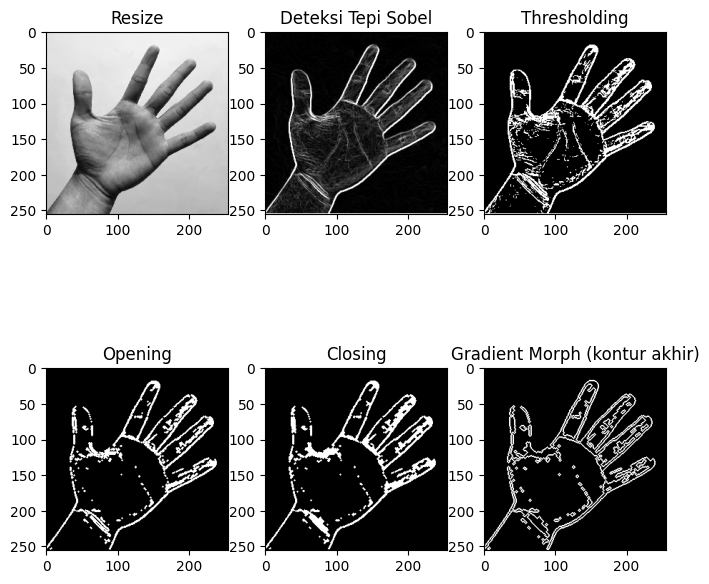

In [ ]:
tangan_exp_edge = sobel_edge_detection(tangan)
tangan_exp_thres = thresholding(tangan_exp_edge, 55)

tangan_exp_open = opening(tangan_exp_thres, kernel_cross)

tangan_exp_close = closing(tangan_exp_open, kernel_cross)

tangan_exp_grad = morphological_gradient(tangan_exp_close, kernel_cross)

plt.figure(figsize=(8, 8))

plt.subplot(2, 3, 1)
plt.title("Resize")
plt.imshow(tangan, cmap='gray')
plt.subplot(2, 3, 2)
plt.title("Deteksi Tepi Sobel")
plt.imshow(tangan_exp_edge, cmap='gray')
plt.subplot(2, 3, 3)
plt.title("Thresholding")
plt.imshow(tangan_exp_thres, cmap='gray')
plt.subplot(2, 3, 4)
plt.title("Opening")
plt.imshow(tangan_exp_open, cmap='gray')
plt.subplot(2, 3, 5)
plt.title("Closing")
plt.imshow(tangan_exp_close, cmap='gray')
plt.subplot(2, 3, 6)
plt.title("Gradient Morph (kontur akhir)")
plt.imshow(tangan_exp_grad, cmap='gray')

plt.show()

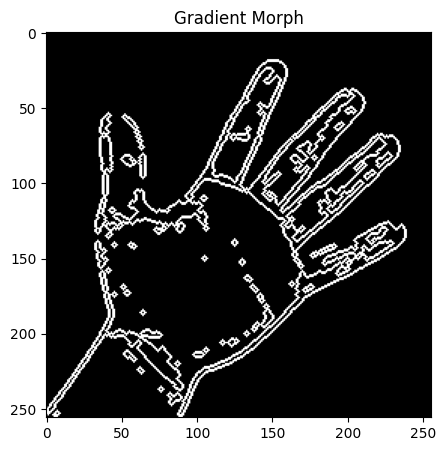

In [144]:
plt.figure(figsize=(5, 5))
plt.title("Gradient Morph")
plt.imshow(tangan_exp_grad, cmap='gray')

Kode tersebut berfungsi untuk menampilkan gambar bernama tangan_exp_grad ke layar dengan judul "Gradient Morph". Gambar ditampilkan dalam mode hitam-putih (grayscale) dengan ukuran jendela visualisasi sebesar $5 \times 5$ inci.

## Analisis Eksplorasi Mandiri:

**Deteksi Tepi Sobel** — Operator Sobel menghitung gradien intensitas untuk menemukan area transisi tajam, yaitu batas tepi telapak tangan. Hasilnya berupa peta kekuatan tepi dalam nilai 0-255.

**Thresholding** — Peta tepi dari Sobel dikonversi menjadi citra biner. Nilai threshold 50 dipilih untuk mempertahankan tepi yang cukup kuat sambil membuang respons lemah yang merupakan noise.

**Opening** — Membersihkan titik-titik noise kecil yang lolos dari thresholding tanpa merusak struktur garis kontur yang lebih panjang dan kontinu. Kernel cross dipilih agar tidak terlalu agresif mengikis garis diagonal.

**Gradient Morfologi** — Sebagai tahap akhir, gradient morfologi mempertegas kontur dengan mengambil selisih dilasi dan erosi. Hasilnya adalah garis kontur yang tipis, bersih, dan tepat berada di batas objek, menghasilkan outline telapak tangan yang jelas.